In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print("Dataset berhasil dibaca")

Dataset berhasil dibaca


In [4]:
print("Contoh data ratings:")
display(ratings.head(10))

Contoh data ratings:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [5]:
print("Contoh data movies:")
display(movies.head(10))

Contoh data movies:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [6]:
ringkasan_dataset = pd.DataFrame({
    "Dataset": ["ratings.csv", "movies.csv"],
    "Jumlah Baris": [ratings.shape[0], movies.shape[0]],
    "Jumlah Kolom": [ratings.shape[1], movies.shape[1]],
    "Nama Kolom": [
        ", ".join(ratings.columns),
        ", ".join(movies.columns)
    ]
})

display(ringkasan_dataset)

,Dataset,Jumlah Baris,Jumlah Kolom,Nama Kolom
0,ratings.csv,100836,4,"userId, movieId, rating, timestamp"
1,movies.csv,9742,3,"movieId, title, genres"


In [7]:
info_ratings = pd.DataFrame({
    "Kolom": ratings.columns,
    "Tipe Data": ratings.dtypes.astype(str).values,
    "Jumlah Missing": ratings.isnull().sum().values,
    "Persentase Missing (%)": (
        ratings.isnull().sum().values / len(ratings) * 100
    ).round(2)
})

print("Informasi ratings.csv")
display(info_ratings)

Informasi ratings.csv


,Kolom,Tipe Data,Jumlah Missing,Persentase Missing (%)
0,userId,int64,0,0.0
1,movieId,int64,0,0.0
2,rating,float64,0,0.0
3,timestamp,int64,0,0.0


In [8]:
info_movies = pd.DataFrame({
    "Kolom": movies.columns,
    "Tipe Data": movies.dtypes.astype(str).values,
    "Jumlah Missing": movies.isnull().sum().values,
    "Persentase Missing (%)": (
        movies.isnull().sum().values / len(movies) * 100
    ).round(2)
})

print("Informasi movies.csv")
display(info_movies)

Informasi movies.csv


,Kolom,Tipe Data,Jumlah Missing,Persentase Missing (%)
0,movieId,int64,0,0.0
1,title,str,0,0.0
2,genres,str,0,0.0


In [9]:
duplikat_data = pd.DataFrame({
    "Dataset": ["ratings.csv", "movies.csv"],
    "Jumlah Data Duplikat": [
        ratings.duplicated().sum(),
        movies.duplicated().sum()
    ]
})

display(duplikat_data)

,Dataset,Jumlah Data Duplikat
0,ratings.csv,0
1,movies.csv,0


In [10]:
statistik_rating = pd.DataFrame({
    "Statistik": [
        "Jumlah Rating",
        "Rating Minimum",
        "Rating Maksimum",
        "Rata-rata Rating",
        "Median Rating",
        "Standar Deviasi"
    ],
    "Nilai": [
        ratings["rating"].count(),
        ratings["rating"].min(),
        ratings["rating"].max(),
        ratings["rating"].mean(),
        ratings["rating"].median(),
        ratings["rating"].std()
    ]
})

statistik_rating["Nilai"] = statistik_rating["Nilai"].round(2)

display(statistik_rating)

,Statistik,Nilai
0,Jumlah Rating,100836.00
1,Rating Minimum,0.50
2,Rating Maksimum,5.00
3,Rata-rata Rating,3.50
4,Median Rating,3.50
5,Standar Deviasi,1.04


In [11]:
jumlah_user = ratings["userId"].nunique()
jumlah_film = ratings["movieId"].nunique()
jumlah_rating = len(ratings)

sparsity = (1 - (jumlah_rating / (jumlah_user * jumlah_film))) * 100

ringkasan_interaksi = pd.DataFrame({
    "Informasi": [
        "Jumlah Pengguna",
        "Jumlah Film yang Memiliki Rating",
        "Total Rating",
        "Tingkat Sparsity Matriks Rating (%)"
    ],
    "Nilai": [
        jumlah_user,
        jumlah_film,
        jumlah_rating,
        round(sparsity, 2)
    ]
})

display(ringkasan_interaksi)

,Informasi,Nilai
0,Jumlah Pengguna,610.0
1,Jumlah Film yang Memiliki Rating,9724.0
2,Total Rating,100836.0
3,Tingkat Sparsity Matriks Rating (%),98.3


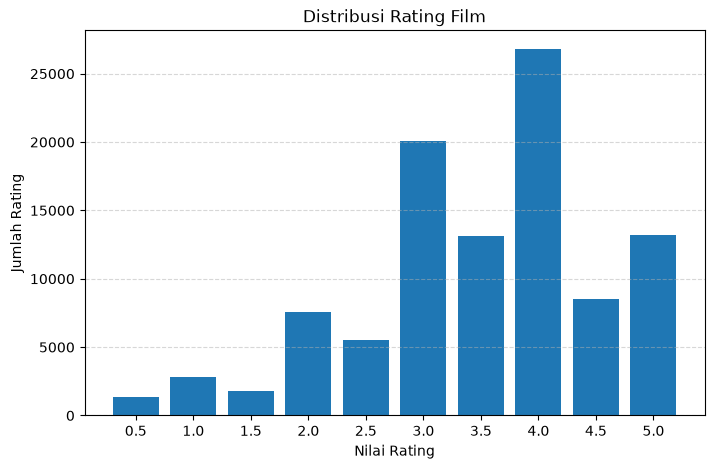

In [12]:
rating_count = ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_count.index.astype(str), rating_count.values)

plt.title("Distribusi Rating Film")
plt.xlabel("Nilai Rating")
plt.ylabel("Jumlah Rating")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [13]:
jumlah_rating_film = ratings.groupby("movieId").agg(
    jumlah_rating=("rating", "count"),
    rata_rata_rating=("rating", "mean")
).reset_index()

film_populer = jumlah_rating_film.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left"
)

film_populer = film_populer.sort_values(
    by=["jumlah_rating", "rata_rata_rating"],
    ascending=[False, False]
).head(10)

display(film_populer)

,movieId,jumlah_rating,rata_rata_rating,title,genres
314,356,329,4.164134,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,4.429022,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,4.197068,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,4.161290,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,4.192446,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,4.231076,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,3.750000,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,4.031646,Braveheart (1995),Action|Drama|War
507,589,224,3.970982,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,4.225000,Schindler's List (1993),Drama|War


In [14]:
user_aktif = ratings.groupby("userId").agg(
    jumlah_rating=("rating", "count"),
    rata_rata_rating=("rating", "mean")
).reset_index()

user_aktif = user_aktif.sort_values(
    by="jumlah_rating",
    ascending=False
).head(10)

display(user_aktif)

,userId,jumlah_rating,rata_rata_rating
413,414,2698,3.391957
598,599,2478,2.642050
473,474,2108,3.398956
447,448,1864,2.847371
273,274,1346,3.235884
609,610,1302,3.688556
67,68,1260,3.233730
379,380,1218,3.673235
605,606,1115,3.657399
287,288,1055,3.145972
